In [1]:
# PROJECT  : Credit Risk Analysis
# NOTEBOOK : 04 — Machine Learning Model
# AUTHOR   : Simran Kumari Singh
# TOOL     : Google Colab (Python)

In [2]:
# Import all tools needed for machine learning

import pandas as pd                    # for working with tables
import numpy as np                     # for math calculations
import matplotlib.pyplot as plt        # for drawing charts

# sklearn = scikit-learn = Python's machine learning library
# We import specific tools from it:
from sklearn.linear_model import LogisticRegression # LogisticRegression = the ML algorithm for YES/NO prediction problems
from sklearn.model_selection import train_test_split # train_test_split = splits data into training set and testing set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #accuracy_score    = tells us what % of predictions were correct, confusion_matrix  = shows breakdown of correct vs wrong predictions, classification_report = detailed performance summary
from sklearn.preprocessing import LabelEncoder, StandardScaler # LabelEncoder   = converts text values to numbers , StandardScaler = puts all numbers on same scale so model is fair

# Make charts look sharp and clear
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully!")
print("We are ready to build our ML model.")

All libraries imported successfully!
We are ready to build our ML model.


In [4]:
# Load the cleaned dataset
df = pd.read_csv('Credit_Risk_Clean.csv')

print("Dataset loaded successfully!")
print(f"Total rows    : {df.shape[0]:,}")   # number of loan records
print(f"Total columns : {df.shape[1]}")      # number of data fields
print("\nWe will use this data to train our ML model")

Dataset loaded successfully!
Total rows    : 32,581
Total columns : 19

We will use this data to train our ML model


In [5]:
# SELECT WHICH COLUMNS THE MODEL WILL LEARN FROM

# 1. Select columns that logically affect default risk
features = [
    'person_age',
    'person_income',
    'person_emp_length',            # how many years they have been employed
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',          # loan amount as percentage of income
    'cb_person_cred_hist_length',   # how many years of credit history
    'loan_grade',
    'person_home_ownership',
    'cb_person_default_on_file'     # has this person defaulted before? Y/N
]

# 2. Create a clean copy of data with only selected columns
df_ml = df[features + ['loan_status']].copy()

print("Features selected for ML model:")
print("-" * 35)
for i, f in enumerate(features, 1):
    print(f"  {i:2}. {f}")
print(f"\nTarget column : loan_status")
print(f"  (0 = Not Defaulted, 1 = Defaulted)")
print(f"\nTotal records : {len(df_ml):,}")


Features selected for ML model:
-----------------------------------
   1. person_age
   2. person_income
   3. person_emp_length
   4. loan_amnt
   5. loan_int_rate
   6. loan_percent_income
   7. cb_person_cred_hist_length
   8. loan_grade
   9. person_home_ownership
  10. cb_person_default_on_file

Target column : loan_status
  (0 = Not Defaulted, 1 = Defaulted)

Total records : 32,581


In [6]:
# CONVERT TEXT COLUMNS TO NUMBERS
#  LabelEncoder automatically converts:
#   loan_grade            : A=0, B=1, C=2, D=3, E=4, F=5, G=6
#   person_home_ownership : MORTGAGE=0, OTHER=1, OWN=2, RENT=3
#   cb_person_default_on_file : N=0, Y=1

# 1. Create LabelEncoder object
le = LabelEncoder()

# 2. List of columns that have text values
text_columns = ['loan_grade', 'person_home_ownership', 'cb_person_default_on_file']

# 3. Loop through each text column and convert to numbers
for col in text_columns:
    df_ml[col] = le.fit_transform(df_ml[col])
    # fit_transform = learn the unique values + convert to numbers
    print(f"'{col}' — text converted to numbers successfully")

print("\nAll text columns are now numbers!")
print("Checking data types after conversion:")
print(df_ml.dtypes)


'loan_grade' — text converted to numbers successfully
'person_home_ownership' — text converted to numbers successfully
'cb_person_default_on_file' — text converted to numbers successfully

All text columns are now numbers!
Checking data types after conversion:
person_age                      int64
person_income                   int64
person_emp_length               int64
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_cred_hist_length      int64
loan_grade                      int64
person_home_ownership           int64
cb_person_default_on_file       int64
loan_status                     int64
dtype: object


In [7]:
# SPLIT DATA INTO TRAINING SET AND TESTING SET

X = df_ml.drop('loan_status', axis=1)   # drop target = keep features
y = df_ml['loan_status']                 # keep only target column

# Split X and y together into train and test portions
# test_size=0.2 means 20% goes to test, 80% goes to train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Data split complete!")
print(f"\n Training set : {X_train.shape[0]:,} records (80%)")
print(f" Testing set  : {X_test.shape[0]:,} records (20%)")
print(f"\n Model will LEARN from {X_train.shape[0]:,} past loan records")
print(f" Model will be TESTED on {X_test.shape[0]:,} unseen records")


Data split complete!

 Training set : 26,064 records (80%)
 Testing set  : 6,517 records (20%)

 Model will LEARN from 26,064 past loan records
 Model will be TESTED on 6,517 unseen records


In [8]:
# SCALE ALL FEATURES TO SAME RANGE

# Problem without scaling:
#   person_income     = 50,000  (very large number)
#   loan_percent_income = 0.35  (very small number)

# StandardScaler fixes this by converting all values
# to a range roughly between -3 and +3

# 1. Create StandardScaler object
scaler = StandardScaler()

# 2. fit_transform on train = learn the scale from train data + apply it
X_train_scaled = scaler.fit_transform(X_train)

# 3. transform only on test = apply SAME scale learned from train data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")
print("All 10 features are now on the same scale")
print("Model will now treat all features fairly")

Feature scaling complete!
All 10 features are now on the same scale
Model will now treat all features fairly


In [9]:
# TRAIN THE MACHINE LEARNING MODEL

# Using Logistic Regression

# 1. Create the Logistic Regression model
model = LogisticRegression(max_iter=500, random_state=42)

# 2. Train the model on scaled training data
model.fit(X_train_scaled, y_train)
# X_train_scaled = the features (inputs)
# y_train = the answers (loan_status values)

print("Model training complete!")
print(f"Model learned from {X_train.shape[0]:,} loan records")
print(f"Model used {X_train.shape[1]} features to learn")
print("\nNow we will check how accurate the model is...")

Model training complete!
Model learned from 26,064 loan records
Model used 10 features to learn

Now we will check how accurate the model is...


In [10]:
# CHECK MODEL ACCURACY

# 1. Make predictions on test data (data model has never seen)
y_pred = model.predict(X_test_scaled)

# 2. Calculate what percentage of predictions were correct
accuracy = accuracy_score(y_test, y_pred) * 100

print("=" * 45)
print(f"  MODEL ACCURACY : {accuracy:.2f}%")
print("=" * 45)

# 3. Calculate exact numbers
correct_predictions = int(accuracy / 100 * len(y_test))
wrong_predictions = len(y_test) - correct_predictions

print(f"\n Total test records    : {len(y_test):,}")
print(f" Correct predictions   : {correct_predictions:,}")
print(f" Wrong predictions     : {wrong_predictions:,}")
print(f"\n Accuracy of {accuracy:.2f}% means model correctly")
print(f" predicted {correct_predictions:,} out of {len(y_test):,} customers")

  MODEL ACCURACY : 83.63%

 Total test records    : 6,517
 Correct predictions   : 5,450
 Wrong predictions     : 1,067

 Accuracy of 83.63% means model correctly
 predicted 5,450 out of 6,517 customers


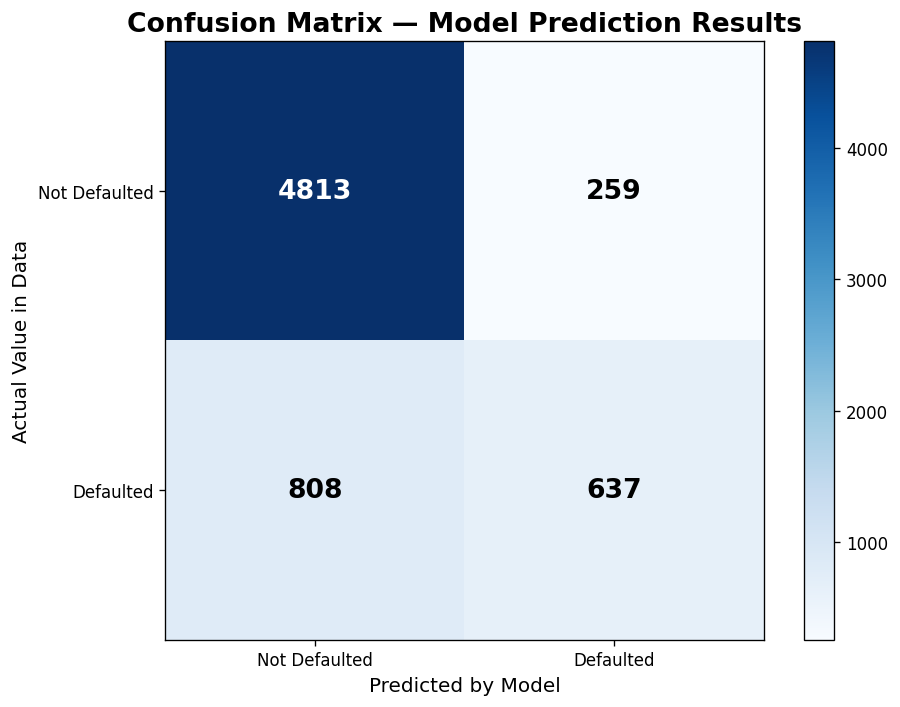

Confusion Matrix Explanation:
  Correctly said NOT default : 4,813  ✅
  Correctly said DEFAULT     : 637  ✅
  Wrongly flagged as default : 259  ❌
  Missed actual defaulters   : 808  ❌ (most dangerous)


In [11]:
# CONFUSION MATRIX — Detailed breakdown of predictions
# For a bank, False Negative is MOST dangerous
# (approving a loan for someone who will default)

# 1. Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred) # y_test = actual values, y_pred = model's predictions

# 2. Draw confusion matrix as a colored grid
plt.figure(figsize=(8, 6))

img = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(img)  # add color scale bar on the right

# 3. Add title and axis labels
plt.title('Confusion Matrix — Model Prediction Results',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted by Model', fontsize=12)
plt.ylabel('Actual Value in Data', fontsize=12)

# 4. Label the tick marks on each axis
plt.xticks([0, 1], ['Not Defaulted', 'Defaulted'])
plt.yticks([0, 1], ['Not Defaulted', 'Defaulted'])

# 5. Add the actual numbers inside each cell of the grid
for i in range(2):           # loop through rows
    for j in range(2):       # loop through columns
        plt.text(
            j, i,            # position in grid
            str(cm[i][j]),   # the number to show
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            # white text on dark cells, black text on light cells
            color='white' if cm[i][j] > cm.max() / 2 else 'black'
        )

plt.tight_layout()
plt.show()

# 6. Print explanation of each number
print("Confusion Matrix Explanation:")
print(f"  Correctly said NOT default : {cm[0][0]:,}  ✅")
print(f"  Correctly said DEFAULT     : {cm[1][1]:,}  ✅")
print(f"  Wrongly flagged as default : {cm[0][1]:,}  ❌")
print(f"  Missed actual defaulters   : {cm[1][0]:,}  ❌ (most dangerous)")

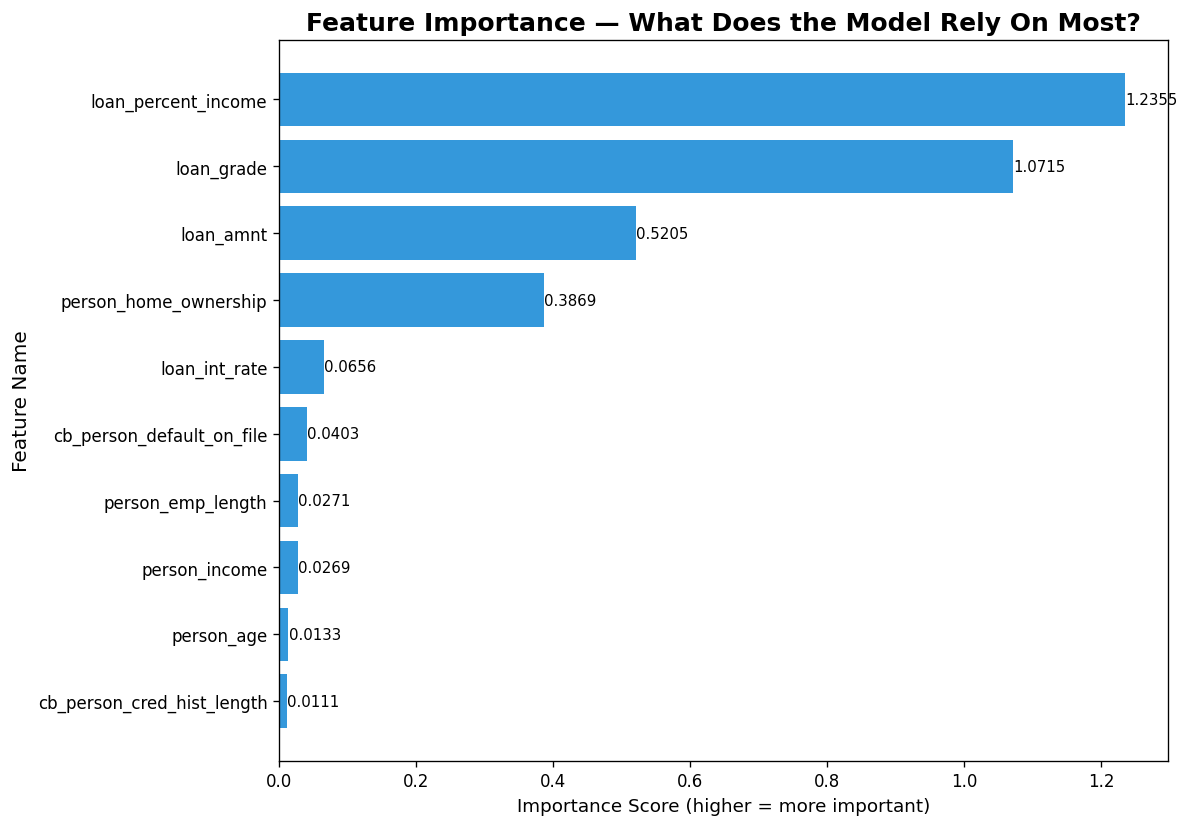

Top 3 Most Important Features:
  1. loan_percent_income (score: 1.2355)
  2. loan_grade (score: 1.0715)
  3. loan_amnt (score: 0.5205)


In [12]:
# Which factor matters most?(FEATURE IMPORTANCE)

# 1. Extract the model's learned weights for each feature
importance = pd.DataFrame({
    'Feature': X.columns,              # feature names
    'Importance': abs(model.coef_[0])  # how important each feature is
}) # model.coef_[0] = the weight the model gave to each feature, abs() = take absolute value (ignore +/- sign, just want size)

# 2. Sort from most important to least important
importance = importance.sort_values('Importance', ascending=True)

# 3. Draw horizontal bar chartDraw horizontal bar chart
plt.figure(figsize=(10, 7))
bars = plt.barh(
    importance['Feature'],     # feature names on y axis
    importance['Importance'],  # importance scores on x axis
    color='#3498db'            # blue color for all bars
)

plt.title('Feature Importance — What Does the Model Rely On Most?',
          fontsize=15, fontweight='bold')
plt.xlabel('Importance Score (higher = more important)', fontsize=11)
plt.ylabel('Feature Name', fontsize=12)

# 4. Add importance score number at end of each bar
for bar, val in zip(bars, importance['Importance']):
    plt.text(
        val + 0.0005,                         # just to the right of bar
        bar.get_y() + bar.get_height() / 2,   # middle height of bar
        f'{val:.4f}',                          # show 4 decimal places
        va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

# 5. Print top 3 most important features
print("Top 3 Most Important Features:")
top3 = importance.sort_values('Importance', ascending=False).head(3)
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {rank}. {row['Feature']} (score: {row['Importance']:.4f})")

In [13]:
# PREDICT DEFAULT PROBABILITY FOR ONE NEW CUSTOMER
# Loan officer can enter customer details and get instant risk assessment before approval
print("LOAN DEFAULT RISK PREDICTOR")
print("=" * 48)
print("Checking a new customer's default probability...")
print("=" * 48)
print("\nCustomer Details:")
print("  Age                : 25 years old")
print("  Annual Income      : $30,000")
print("  Employment Length  : 2 years")
print("  Loan Amount        : $10,000")
print("  Interest Rate      : 18.5%")
print("  Loan % of Income   : 33%")
print("  Credit History     : 3 years")
print("  Loan Grade         : E (High Risk Grade)")
print("  Home Ownership     : RENT")
print("  Past Default       : Yes (Y)")
print("=" * 48)

# 2. Create a table with this one customer's data
sample_customer = pd.DataFrame({
    'person_age': [25],
    'person_income': [30000],
    'person_emp_length': [2.0],
    'loan_amnt': [10000],
    'loan_int_rate': [18.5],
    'loan_percent_income': [0.33],
    'cb_person_cred_hist_length': [3],
    'loan_grade': [4],              # E = 4
    'person_home_ownership': [3],   # RENT = 3
    'cb_person_default_on_file': [1]  # Y = 1
})

# 3. Scale this customer's data using the SAME scaler we trained with
sample_scaled = scaler.transform(sample_customer)

probability = model.predict_proba(sample_scaled)[0][1] * 100

print(f"\n DEFAULT PROBABILITY : {probability:.2f}%")
print()
# predict_proba() gives probability of each outcome
# [0] = first (and only) customer in our sample
# [1] = probability of class 1 = probability of DEFAULT

# 4. Give recommendation based on probability
if probability >= 50:
    print(" RISK LEVEL      :  HIGH RISK")
    print(" RECOMMENDATION  : Do Not Approve This Loan")
elif probability >= 30:
    print(" RISK LEVEL      :  MEDIUM RISK")
    print(" RECOMMENDATION  : Review Carefully Before Approving")
else:
    print(" RISK LEVEL      :  LOW RISK")
    print(" RECOMMENDATION  : Safe to Approve")

print("=" * 48)

LOAN DEFAULT RISK PREDICTOR
Checking a new customer's default probability...

Customer Details:
  Age                : 25 years old
  Annual Income      : $30,000
  Employment Length  : 2 years
  Loan Amount        : $10,000
  Interest Rate      : 18.5%
  Loan % of Income   : 33%
  Credit History     : 3 years
  Loan Grade         : E (High Risk Grade)
  Home Ownership     : RENT
  Past Default       : Yes (Y)

 DEFAULT PROBABILITY : 93.56%

 RISK LEVEL      :  HIGH RISK
 RECOMMENDATION  : Do Not Approve This Loan


In [14]:
# FINAL PROJECT SUMMARY
# Complete overview of what this ML model achieved

print("=" * 55)
print("    CREDIT RISK ML MODEL — COMPLETE SUMMARY")
print("=" * 55)

print(f"\n DATASET")
print(f"   Total Records          : {len(df):,}")
print(f"   Features Used          : {X_train.shape[1]}")
print(f"   Target Variable        : loan_status (0 or 1)")

print(f"\n MODEL TRAINING")
print(f"   Algorithm              : Logistic Regression")
print(f"   Training Records       : {X_train.shape[0]:,} (80%)")
print(f"   Testing Records        : {X_test.shape[0]:,} (20%)")

print(f"\n MODEL PERFORMANCE")
print(f"   Accuracy               : {accuracy:.2f}%")
print(f"   Correct Predictions    : {int(accuracy/100 * len(y_test)):,}")

print(f"\n TOP 3 DEFAULT PREDICTORS")
top3 = importance.sort_values('Importance', ascending=False).head(3)
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"   {rank}. {row['Feature']}")

print(f"\n SKILLS DEMONSTRATED")
print(f"   Pandas    — data loading and manipulation")
print(f"   Sklearn   — LabelEncoder, StandardScaler,")
print(f"               LogisticRegression, train_test_split")
print(f"   Matplotlib — confusion matrix, feature importance chart")

print("\n" + "=" * 55)
print(" Notebook 4 Complete! Python Phase 100% Done!")
print(" Next Phase: Power BI Dashboard")
print("=" * 55)

    CREDIT RISK ML MODEL — COMPLETE SUMMARY

 DATASET
   Total Records          : 32,581
   Features Used          : 10
   Target Variable        : loan_status (0 or 1)

 MODEL TRAINING
   Algorithm              : Logistic Regression
   Training Records       : 26,064 (80%)
   Testing Records        : 6,517 (20%)

 MODEL PERFORMANCE
   Accuracy               : 83.63%
   Correct Predictions    : 5,450

 TOP 3 DEFAULT PREDICTORS
   1. loan_percent_income
   2. loan_grade
   3. loan_amnt

 SKILLS DEMONSTRATED
   Pandas    — data loading and manipulation
   Sklearn   — LabelEncoder, StandardScaler,
               LogisticRegression, train_test_split
   Matplotlib — confusion matrix, feature importance chart

 Notebook 4 Complete! Python Phase 100% Done!
 Next Phase: Power BI Dashboard
